In [ ]:
import matplotlib.pyplot as pl
import numpy as np

In [ ]:
from tqdm import tqdm

from fit2082.demo.utils import Dataset

In [ ]:
from fit2082.boost import HashBoost


***

In [ ]:
path = "../data/"

dataset = "Pedestrian"

fn_X = f"{path}/{dataset}/{dataset}_X.npy"
fn_Y = f"{path}/{dataset}/{dataset}_y.npy"

data = Dataset(fn_X, fn_Y)

data.batch_size = 4_096

num_classes = len(data.classes)

f0 = np.loadtxt(f"{path}/{dataset}/test_indices_fold_0.txt")

ix = np.setdiff1d(np.arange(data.shape[0]), f0)

n_tr = 32_768 * 2

n_va = 4_096
n_te = 4_096

np.random.seed(123)
np.random.shuffle(ix)

TR = ix[:n_tr]
VA = ix[n_tr : n_tr + n_va]
TE = ix[n_tr + n_va : n_tr + n_va + n_te]

data_TR = data[TR]
data_VA = data[VA]
data_TE = data[TE]

_size = 1_024

for X, Y in data_TR:
    X_TR = X.reshape(X.shape[0], -1)[:_size].astype(np.float32)
    Y_TR = Y[:_size].astype(np.int32)
    break

for X, Y in data_VA:
    X_VA = X.reshape(X.shape[0], -1)[:_size].astype(np.float32)
    Y_VA = Y[:_size].astype(np.int32)
    break

data.close()

***

In [5]:
model = HashBoost(
    num_classes=num_classes,
    num_bits=8,
    lr=0.1,
    max_num_hashes=1_000,
)

max_epochs = 50

tr_record = []
va_record = []

count = 0


# predictions come back as torch tensors on the model's device
def error(X, Y):
    return (model.predict_proba(X).argmax(-1).cpu().numpy() != Y).mean()


for i in tqdm(range(max_epochs), total=max_epochs, ncols=80):
    for X, Y in data_TR:
        model.fit_batch(
            X.reshape(X.shape[0], -1).squeeze().astype(np.float32), Y.astype(np.int32)
        )

        count += 1

    tr_record.append((count, error(X_TR, Y_TR)))
    va_record.append((count, error(X_VA, Y_VA)))

print(f"count -> {count}; model.num_rounds -> {model.num_rounds}")

100%|███████████████████████████████████████████| 50/50 [00:50<00:00,  1.00s/it]

count -> 800; model.num_rounds -> 800


***

# loss curve training / validation

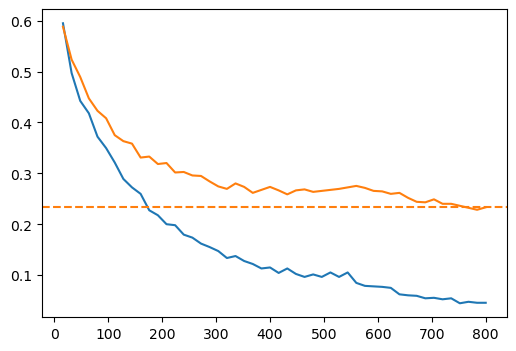

In [6]:
f, a = pl.subplots(1, 1, figsize=(6, 4))

a.plot(*np.array(tr_record).T)
a.plot(*np.array(va_record).T)

a.axhline(va_record[-1][1], ls="--", c="C1")

pl.show()

In [7]:
np.array(va_record)[:, 1].min()

np.float64(0.228515625)

# loss curve vs model depth (how many rounds of boosting)

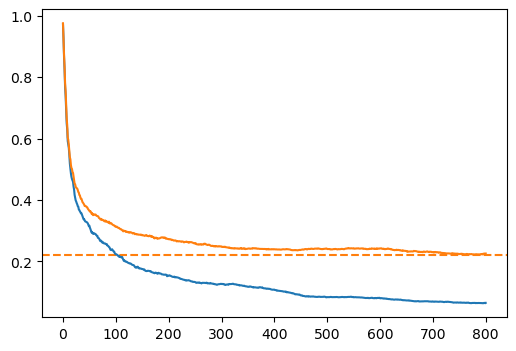

In [8]:
for X, Y in data_TR:
    tr_slope = (
        model.staged_error(
            X.reshape(X.shape[0], -1).squeeze().astype(np.float32), Y.astype(np.int32)
        )
        .cpu()
        .numpy()
    )

    break

for X, Y in data_VA:
    va_slope = (
        model.staged_error(
            X.reshape(X.shape[0], -1).squeeze().astype(np.float32), Y.astype(np.int32)
        )
        .cpu()
        .numpy()
    )

    break

f, a = pl.subplots(1, 1, figsize=(6, 4))

a.axhline(va_slope.min(), ls="--", c="C1")

a.plot(tr_slope)
a.plot(va_slope)

pl.show()

In [9]:
va_slope.min()

np.float64(0.221923828125)

In [10]:
tr_slope[-1], va_slope[-1]

(np.float64(0.064453125), np.float64(0.225341796875))